In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("Dataset/Processed/cleaned_crime.csv")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date", "Latitude", "Longitude"])

df_2023 = df[df["Year"] == 2023].copy()

# quarter labels like 2023Q1, 2023Q2...
df_2023["quarter"] = df_2023["Date"].dt.to_period("Q").astype(str)

print(df_2023.shape)
print(df_2023["quarter"].value_counts().sort_index())

(261243, 6)
quarter
2023Q1    60071
2023Q2    65486
2023Q3    70703
2023Q4    64983
Name: count, dtype: int64


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

EARTH_RADIUS_M = 6371000

def k_distance_elbow(df_points, k=50, sample_n=60000, random_state=42):
    """
    df_points must have columns: Latitude, Longitude
    k = min_samples (typical: 30-150)
    """
    g = df_points.dropna(subset=["Latitude","Longitude"]).copy()
    if len(g) > sample_n:
        g = g.sample(sample_n, random_state=random_state)

    coords = np.radians(g[["Latitude","Longitude"]].to_numpy())

    nn = NearestNeighbors(n_neighbors=k, metric="haversine", algorithm="ball_tree")
    nn.fit(coords)
    dists, _ = nn.kneighbors(coords)  # distances in radians

    # k-th neighbor distance (last column), convert to meters
    kth = dists[:, -1] * EARTH_RADIUS_M
    kth_sorted = np.sort(kth)

    plt.figure(figsize=(8,5))
    plt.plot(kth_sorted)
    plt.title(f"k-distance plot (k = min_samples = {k})")
    plt.xlabel("Points sorted by distance")
    plt.ylabel("k-th nearest neighbor distance (meters)")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    print("Quick eps candidates (meters):")
    for p in [80, 90, 95, 97, 99]:
        print(f"  {p}th percentile: {np.percentile(kth_sorted, p):.1f} m")

    return kth_sorted

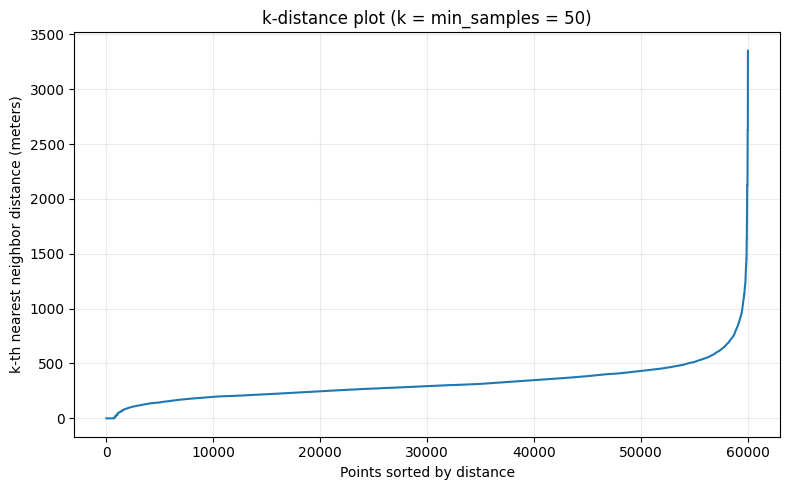

Quick eps candidates (meters):
  80th percentile: 410.7 m
  90th percentile: 489.8 m
  95th percentile: 598.1 m
  97th percentile: 692.6 m
  99th percentile: 954.9 m


In [3]:
df_q1 = df_2023[df_2023["quarter"] == "2023Q1"]
kth_sorted = k_distance_elbow(df_q1, k=50)

In [4]:
from sklearn.cluster import DBSCAN

earth_radius_m = 6371000
eps_m = 300        # keep same as your working run
eps = eps_m / earth_radius_m
min_samples = 50   # keep same

quarter_cluster_summaries = []
quarter_point_outputs = []

for q, g in df_2023.groupby("quarter"):
    g = g.copy()

    coords = np.radians(g[["Latitude", "Longitude"]].to_numpy())

    db = DBSCAN(eps=eps, min_samples=min_samples, metric="haversine", algorithm="ball_tree")
    labels = db.fit_predict(coords)
    g["cluster"] = labels

    # Save point-level (optional: sample if too large)
    quarter_point_outputs.append(g[["Date","Primary Type","Latitude","Longitude","Year","quarter","cluster"]])

    # Cluster summary (exclude noise)
    clustered = g[g["cluster"] != -1]
    summary = (
        clustered.groupby("cluster")
        .agg(
            size=("cluster","count"),
            lat=("Latitude","mean"),
            lon=("Longitude","mean")
        )
        .reset_index()
    )
    summary["quarter"] = q

    # Add noise info too (useful for evaluation)
    noise_pct = (labels == -1).mean() * 100
    print(q, "clusters:", summary.shape[0], "noise%:", round(noise_pct,2))

    quarter_cluster_summaries.append(summary)

clusters_by_quarter = pd.concat(quarter_cluster_summaries, ignore_index=True)
clusters_by_quarter.head()

2023Q1 clusters: 85 noise%: 26.2
2023Q2 clusters: 82 noise%: 22.22
2023Q3 clusters: 72 noise%: 20.85
2023Q4 clusters: 76 noise%: 23.45


,cluster,size,lat,lon,quarter
0,0,3323,41.756547,-87.567982,2023Q1
1,1,9100,41.775849,-87.626657,2023Q1
2,2,16706,41.883520,-87.686355,2023Q1
3,3,3766,41.972205,-87.657521,2023Q1
4,4,357,41.808326,-87.668881,2023Q1


In [5]:
def haversine_m(lat1, lon1, lat2, lon2):
    # all inputs in degrees
    R = 6371000
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlmb/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

quarters = sorted(clusters_by_quarter["quarter"].unique())

match_threshold_m = 1500  # 1.5km typical start, tune later

evolution_rows = []

for i in range(len(quarters)-1):
    q1, q2 = quarters[i], quarters[i+1]

    A = clusters_by_quarter[clusters_by_quarter["quarter"] == q1].copy()
    B = clusters_by_quarter[clusters_by_quarter["quarter"] == q2].copy()

    A["matched_to"] = None
    A["match_dist_m"] = np.nan

    B["matched_from"] = None

    # For each cluster in A, find nearest cluster in B
    for idx_a, row_a in A.iterrows():
        dists = haversine_m(row_a["lat"], row_a["lon"], B["lat"].values, B["lon"].values)
        j = int(np.argmin(dists))
        best_dist = float(dists[j])

        if best_dist <= match_threshold_m:
            # record match (many-to-one possible; we'll allow it for MVP)
            A.at[idx_a, "matched_to"] = int(B.iloc[j]["cluster"])
            A.at[idx_a, "match_dist_m"] = best_dist

    # Mark B clusters that were matched by any A
    matched_targets = set(A["matched_to"].dropna().astype(int).tolist())
    B["matched_from"] = B["cluster"].apply(lambda x: int(x) if int(x) in matched_targets else None)

    # Build evolution labels
    for _, r in A.iterrows():
        evolution_rows.append({
            "from_quarter": q1,
            "to_quarter": q2,
            "cluster": int(r["cluster"]),
            "size": int(r["size"]),
            "status": "persisted" if pd.notna(r["matched_to"]) else "disappeared",
            "matched_cluster": int(r["matched_to"]) if pd.notna(r["matched_to"]) else None,
            "match_dist_m": float(r["match_dist_m"]) if pd.notna(r["match_dist_m"]) else None,
        })

    # emerged in q2 = not matched from q1
    for _, r in B.iterrows():
        if r["matched_from"] is None:
            evolution_rows.append({
                "from_quarter": q1,
                "to_quarter": q2,
                "cluster": int(r["cluster"]),
                "size": int(r["size"]),
                "status": "emerged",
                "matched_cluster": None,
                "match_dist_m": None,
            })

evolution = pd.DataFrame(evolution_rows)
evolution.head()


,from_quarter,to_quarter,cluster,size,status,matched_cluster,match_dist_m
0,2023Q1,2023Q2,0,3323,disappeared,NaN,NaN
1,2023Q1,2023Q2,1,9100,persisted,0.0,950.271369
2,2023Q1,2023Q2,2,16706,persisted,1.0,428.027922
3,2023Q1,2023Q2,3,3766,persisted,2.0,238.335998
4,2023Q1,2023Q2,4,357,persisted,27.0,1353.086364


In [6]:
import os
os.makedirs("outputs/tables", exist_ok=True)

clusters_by_quarter.to_csv("outputs/tables/quarterly_cluster_summary_2023.csv", index=False)
evolution.to_csv("outputs/tables/hotspot_evolution_2023.csv", index=False)

print("Saved:")
print("- outputs/tables/quarterly_cluster_summary_2023.csv")
print("- outputs/tables/hotspot_evolution_2023.csv")

Saved:
- outputs/tables/quarterly_cluster_summary_2023.csv
- outputs/tables/hotspot_evolution_2023.csv


In [7]:
# hotspots per quarter
hotspots_per_q = clusters_by_quarter.groupby("quarter")["cluster"].nunique().reset_index(name="n_hotspots")
print(hotspots_per_q)

# persistence rate between consecutive quarters
persist_rate = (
    evolution[evolution["status"].isin(["persisted","disappeared"])]
    .groupby(["from_quarter","to_quarter"])["status"]
    .value_counts(normalize=True)
    .rename("rate")
    .reset_index()
)

persist_rate = persist_rate[persist_rate["status"]=="persisted"]
print(persist_rate)

  quarter  n_hotspots
0  2023Q1          85
1  2023Q2          82
2  2023Q3          72
3  2023Q4          76
  from_quarter to_quarter     status      rate
0       2023Q1     2023Q2  persisted  0.823529
2       2023Q2     2023Q3  persisted  0.841463
4       2023Q3     2023Q4  persisted  0.833333


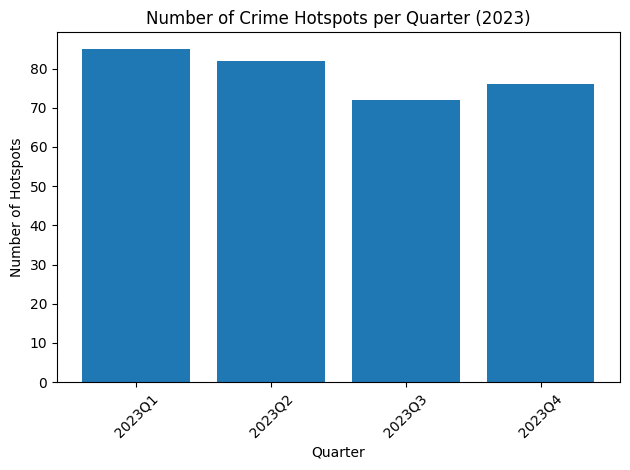

In [8]:
import matplotlib.pyplot as plt

# Hotspots per quarter (already computed as hotspots_per_q)
plt.figure()
plt.bar(hotspots_per_q["quarter"], hotspots_per_q["n_hotspots"])
plt.xlabel("Quarter")
plt.ylabel("Number of Hotspots")
plt.title("Number of Crime Hotspots per Quarter (2023)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("outputs/hotspots_per_quarter_2023.png")
plt.show()

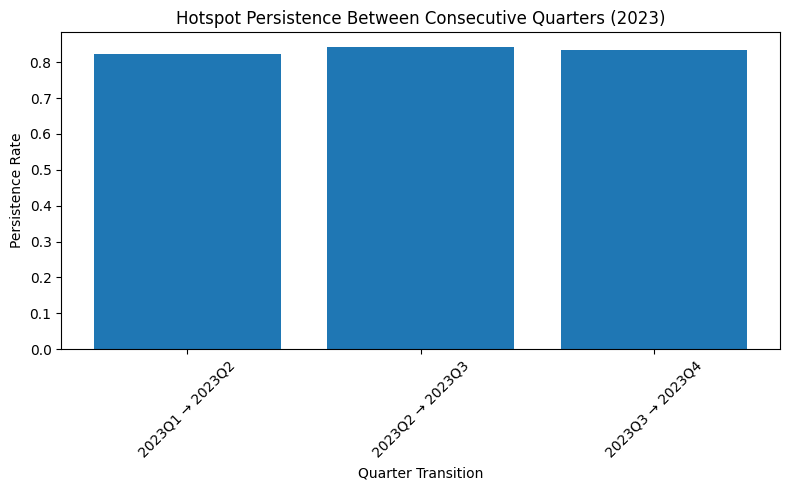

In [9]:
import matplotlib.pyplot as plt

# Prepare labels for persistence transitions
persist_rate["transition"] = (
    persist_rate["from_quarter"] + " → " + persist_rate["to_quarter"]
)

plt.figure(figsize=(8,5))
plt.bar(persist_rate["transition"], persist_rate["rate"])
plt.xlabel("Quarter Transition")
plt.ylabel("Persistence Rate")
plt.title("Hotspot Persistence Between Consecutive Quarters (2023)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("outputs/persistence_rate_2023.png")
plt.show()

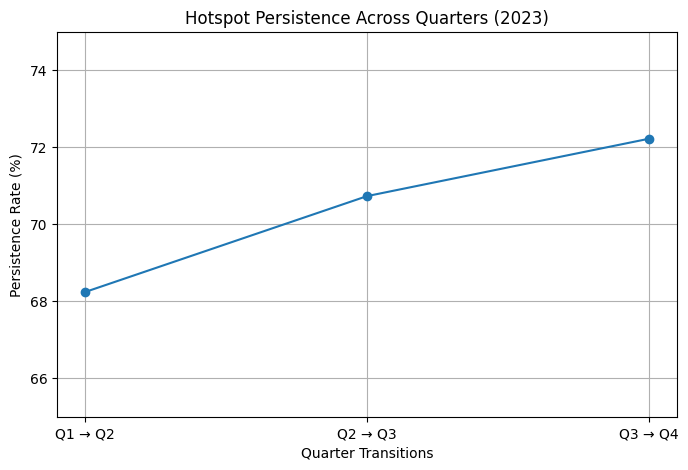

In [34]:
import matplotlib.pyplot as plt

# Data from your results
transitions = ["Q1 → Q2", "Q2 → Q3", "Q3 → Q4"]
persistence = [68.24, 70.73, 72.22]

# Create plot
plt.figure(figsize=(8, 5))
plt.plot(transitions, persistence, marker='o')

# Labels and title
plt.xlabel("Quarter Transitions")
plt.ylabel("Persistence Rate (%)")
plt.title("Hotspot Persistence Across Quarters (2023)")
plt.ylim(65, 75)
# Grid
plt.grid(True)

# Save figure (important for report)
plt.savefig("Outputs/figures/persistence_2023.png", dpi=300, bbox_inches='tight')

# Show plot
plt.show()

In [24]:
# !pip install contextily geopandas shapely

In [25]:
import folium
import numpy as np

def folium_quarter_map(clusters_by_quarter, quarter_name, top_k=20):
    q = clusters_by_quarter[clusters_by_quarter["quarter"] == quarter_name].copy()
    if q.empty:
        raise ValueError(f"No data found for {quarter_name}")

    # Focus color-coding on top K largest clusters; rest are gray
    q = q.sort_values("size", ascending=False).reset_index(drop=True)
    q["rank"] = np.arange(len(q)) + 1
    q["is_top"] = q["rank"] <= top_k

    center = [q["lat"].mean(), q["lon"].mean()]
    m = folium.Map(location=center, zoom_start=11, tiles="CartoDB positron")

    # radius scaling (keeps bubbles reasonable)
    # size -> radius: clamp between 4 and 20
    sizes = q["size"].to_numpy()
    s_min, s_max = np.percentile(sizes, 5), np.percentile(sizes, 95)
    s_max = max(s_max, s_min + 1)

    def scale_radius(s):
        r = 4 + 16 * (s - s_min) / (s_max - s_min)
        return float(np.clip(r, 4, 20))

    # Simple palette for top clusters
    palette = [
        "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
        "#393b79", "#637939", "#8c6d31", "#843c39", "#7b4173",
        "#3182bd", "#e6550d", "#31a354", "#756bb1", "#636363",
    ]

    for i, row in q.iterrows():
        color = palette[i % len(palette)] if row["is_top"] else "#9aa0a6"  # gray for non-top
        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=scale_radius(row["size"]),
            color=color,
            fill=True,
            fill_opacity=0.7,
            popup=folium.Popup(
                f"""
                <b>{quarter_name}</b><br>
                Cluster: {int(row['cluster'])}<br>
                Size: {int(row['size'])}<br>
                Rank: {int(row['rank'])}{' (Top)' if row['is_top'] else ''}
                """,
                max_width=250
            ),
        ).add_to(m)

    # Title
    title_html = f"""
    <h3 style="position: fixed; top: 10px; left: 50px; z-index:9999;
               background: rgba(255,255,255,0.85); padding: 8px 12px;
               border-radius: 8px; font-family: Arial;">
        Crime Hotspots (DBSCAN Centroids) — {quarter_name}<br>
        <span style="font-size:12px;">Top {top_k} clusters colored • others gray • bubble size ~ cluster size</span>
    </h3>
    """
    m.get_root().html.add_child(folium.Element(title_html))

    # Legend
    legend_html = f"""
    <div style="
        position: fixed; bottom: 30px; left: 30px; z-index:9999;
        background: rgba(255,255,255,0.9); padding: 10px 12px;
        border-radius: 8px; font-family: Arial; font-size: 12px;">
        <b>Legend</b><br>
        Colored = Top {top_k} largest hotspots<br>
        Gray = smaller hotspots<br>
        Bubble radius ∝ hotspot size
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))

    return m

In [26]:
folium_quarter_map(clusters_by_quarter, "2023Q1", top_k=20)

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

def static_quarter_map_png(clusters_by_quarter, quarter_name, outpath=None):
    import geopandas as gpd
    import contextily as ctx

    q = clusters_by_quarter[clusters_by_quarter["quarter"] == quarter_name].copy()
    if q.empty:
        raise ValueError(f"No data found for {quarter_name}")

    # Create GeoDataFrame (lon/lat -> geometry)
    gdf = gpd.GeoDataFrame(
        q,
        geometry=gpd.points_from_xy(q["lon"], q["lat"]),
        crs="EPSG:4326"
    ).to_crs(epsg=3857)  # Web Mercator for basemaps

    fig, ax = plt.subplots(figsize=(9, 9))

    # Bubble size scaling (better than /20 guess)
    s = q["size"].to_numpy()
    s = (s / np.percentile(s, 90)) * 300  # normalize
    s = np.clip(s, 10, 600)

    gdf.plot(
        ax=ax,
        markersize=s,
        alpha=0.55
    )

    # Basemap (light)
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

    ax.set_title(f"Crime Hotspots (Centroids) — {quarter_name}", fontsize=14)
    ax.set_axis_off()

    # Save
    if outpath is None:
        outpath = f"outputs/figures/hotspots_{quarter_name}.png"
    import os
    os.makedirs(os.path.dirname(outpath), exist_ok=True)

    plt.tight_layout()
    plt.savefig(outpath, dpi=300)
    plt.show()

    print("Saved:", outpath)

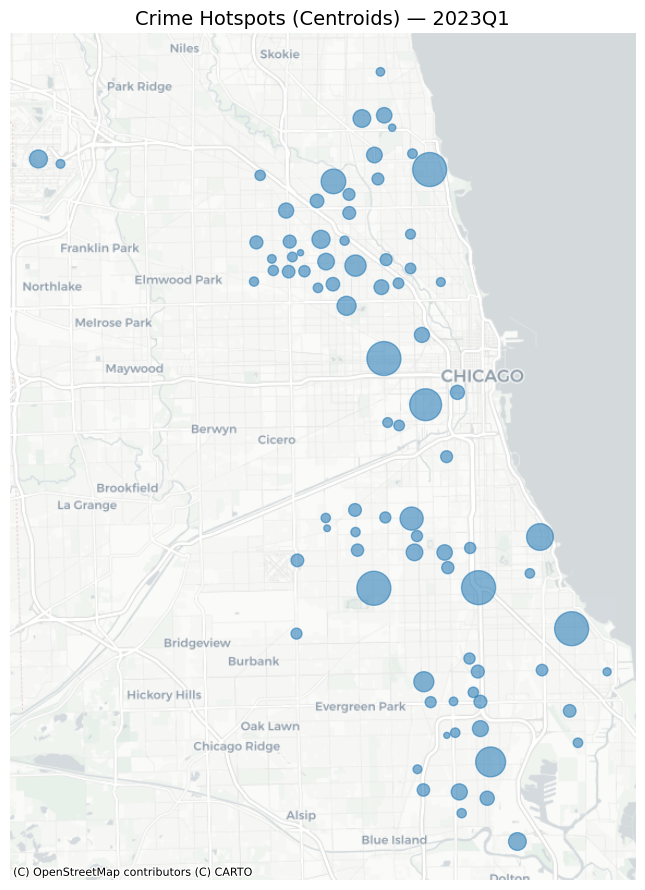

Saved: outputs/figures/hotspots_2023Q1.png


In [28]:
static_quarter_map_png(clusters_by_quarter, "2023Q1")

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def evolution_plot(clusters_by_quarter, evolution, q1, q2, outpath=None, max_lines=60):
    A = clusters_by_quarter[clusters_by_quarter["quarter"] == q1].copy()
    B = clusters_by_quarter[clusters_by_quarter["quarter"] == q2].copy()

    if A.empty or B.empty:
        raise ValueError("Quarter data missing")

    evo = evolution[(evolution["from_quarter"] == q1) & (evolution["to_quarter"] == q2)].copy()

    persisted = evo[evo["status"] == "persisted"].copy()
    disappeared = evo[evo["status"] == "disappeared"].copy()
    emerged = evo[evo["status"] == "emerged"].copy()

    # Persistence rate (from A perspective)
    denom = len(persisted) + len(disappeared)
    rate = (len(persisted) / denom) if denom > 0 else np.nan

    fig, ax = plt.subplots(figsize=(9, 9))

    # Plot centroids
    ax.scatter(A["lon"], A["lat"], alpha=0.55, label=q1)
    ax.scatter(B["lon"], B["lat"], alpha=0.55, label=q2)

    # Draw lines for top persisted (by size) to reduce clutter
    persisted = persisted.sort_values("size", ascending=False).head(max_lines)

    # Build quick lookup for centroid points
    A_idx = A.set_index("cluster")[["lat", "lon"]]
    B_idx = B.set_index("cluster")[["lat", "lon"]]

    for _, r in persisted.iterrows():
        a_id = int(r["cluster"])
        b_id = int(r["matched_cluster"])
        if a_id in A_idx.index and b_id in B_idx.index:
            ax.plot(
                [A_idx.loc[a_id, "lon"], B_idx.loc[b_id, "lon"]],
                [A_idx.loc[a_id, "lat"], B_idx.loc[b_id, "lat"]],
                linewidth=1.6,
                alpha=0.7
            )

    # Mark emerged/disappeared with x markers
    if not disappeared.empty:
        d = A[A["cluster"].isin(disappeared["cluster"].astype(int))]
        ax.scatter(d["lon"], d["lat"], marker="x", color="red", s=80, label="disappeared (from q1)")

    if not emerged.empty:
        e = B[B["cluster"].isin(emerged["cluster"].astype(int))]
        ax.scatter(e["lon"], e["lat"], marker="x", s=80, label="emerged (in q2)")

    ax.set_title(
        f"Hotspot Evolution: {q1} → {q2}\nPersistence rate: {rate:.1%} (based on {denom} q1 clusters)",
        fontsize=14
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()

    if outpath is None:
        outpath = f"outputs/figures/evolution_{q1}_{q2}.png"
    import os
    os.makedirs(os.path.dirname(outpath), exist_ok=True)

    plt.savefig(outpath, dpi=300)
    plt.show()
    print("Saved:", outpath)

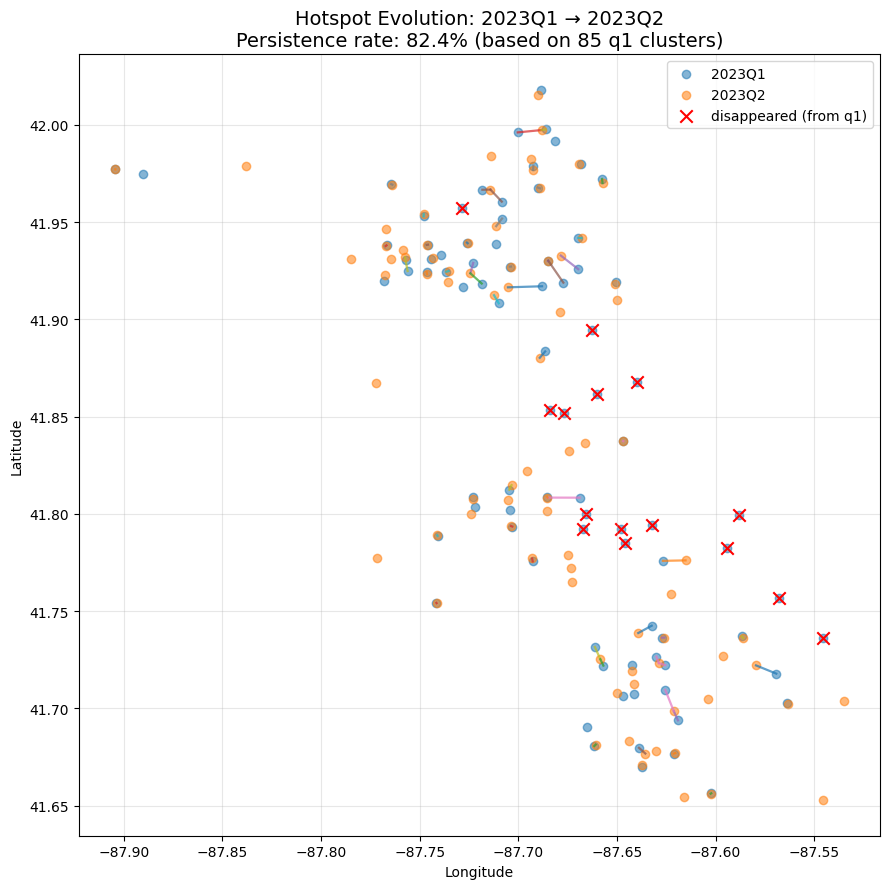

Saved: outputs/figures/evolution_2023Q1_2023Q2.png


In [30]:
evolution_plot(clusters_by_quarter, evolution, "2023Q1", "2023Q2", max_lines=50)